# Cardiac Patient Monitoring System — AI & ML Individual Project

**BinX Tech — AI & Machine Learning Track**

This notebook builds a curriculum-aligned machine learning analysis on a **synthetic**
cardiac dataset. It follows the required work structure from the project guide:

1. Environment & Dataset
2. Data Preparation
3. EDA & Statistics
4. Supervised Baseline
5. Model Comparison
6. Evaluation (cross-validation, confusion matrix, metrics)
7. Feature Engineering & Pipeline
8. Unsupervised Analysis (Clustering + PCA)
9. Documentation / Conclusion

Only tools and techniques covered in Weeks 1-4 are used: Python, NumPy, Pandas,
Matplotlib, Scikit-learn (Logistic Regression, Random Forest, cross-validation,
Pipelines, ColumnTransformer, KMeans, PCA). No deep learning, no APIs, no
identifiable patient data — the dataset is synthetically generated.


## 1. Environment & Dataset

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                              precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
import sklearn
print("scikit-learn:", sklearn.__version__)


numpy: 2.3.5
pandas: 2.3.3
scikit-learn: 1.7.2


**Data dictionary**

| Column | Description |
|---|---|
| age | Patient age in years |
| sex | male / female |
| chest_pain_type | typical_angina / atypical_angina / non_anginal / asymptomatic |
| resting_bp | Resting blood pressure (mm Hg) |
| cholesterol | Serum cholesterol (mg/dl) |
| fasting_bs_high | 1 if fasting blood sugar > 120 mg/dl, else 0 |
| resting_ecg | normal / st_t_abnormality / lv_hypertrophy |
| max_heart_rate | Maximum heart rate achieved |
| exercise_angina | Exercise-induced angina (yes/no) |
| oldpeak | ST depression induced by exercise relative to rest |
| heart_disease | **Target** — 1 = disease present, 0 = no disease |


In [47]:
df = pd.read_csv("cardiac_synthetic.csv")

df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs_high,resting_ecg,max_heart_rate,exercise_angina,oldpeak,heart_disease
0,33,female,non_anginal,147.4,172.2,0,st_t_abnormality,157.8,no,1.26,0
1,66,male,atypical_angina,118.7,333.8,0,normal,130.6,no,0.82,1
2,61,male,typical_angina,116.5,259.9,0,st_t_abnormality,119.0,no,0.15,0
3,50,male,non_anginal,138.8,265.4,0,normal,170.1,yes,1.22,1
4,50,female,asymptomatic,147.8,230.2,0,normal,154.3,yes,0.16,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              605 non-null    int64  
 1   sex              605 non-null    object 
 2   chest_pain_type  605 non-null    object 
 3   resting_bp       593 non-null    float64
 4   cholesterol      587 non-null    float64
 5   fasting_bs_high  605 non-null    int64  
 6   resting_ecg      605 non-null    object 
 7   max_heart_rate   593 non-null    float64
 8   exercise_angina  605 non-null    object 
 9   oldpeak          605 non-null    float64
 10  heart_disease    605 non-null    int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 52.1+ KB


In [49]:
df.describe(include="all")

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs_high,resting_ecg,max_heart_rate,exercise_angina,oldpeak,heart_disease
count,605.000000,605,605,593.000000,587.000000,605.000000,605,593.000000,605,605.000000,605.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,NaN
top,NaN,male,asymptomatic,NaN,NaN,NaN,normal,NaN,no,NaN,NaN
freq,NaN,324,183,NaN,NaN,NaN,329,NaN,392,NaN,NaN
mean,52.947107,NaN,NaN,128.356830,248.039182,0.140496,NaN,150.181113,NaN,0.914099,0.489256
std,14.177465,NaN,NaN,16.850215,51.599981,0.347788,NaN,22.089076,NaN,0.905048,0.500298
min,29.000000,NaN,NaN,90.000000,120.000000,0.000000,NaN,86.800000,NaN,0.000000,0.000000
25%,40.000000,NaN,NaN,117.300000,213.850000,0.000000,NaN,135.600000,NaN,0.290000,0.000000
50%,53.000000,NaN,NaN,129.300000,248.300000,0.000000,NaN,150.200000,NaN,0.650000,0.000000
75%,66.000000,NaN,NaN,140.000000,282.700000,0.000000,NaN,164.600000,NaN,1.220000,1.000000


## 2. Data Preparation

We check for missing values, duplicates, and invalid values, then clean the
dataset with Pandas/NumPy before doing any analysis.


In [50]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         12
cholesterol        18
fasting_bs_high     0
resting_ecg         0
max_heart_rate     12
exercise_angina     0
oldpeak             0
heart_disease       0
dtype: int64

Duplicate rows: 5


In [51]:
df = df.drop_duplicates()

for col in ["cholesterol", "resting_bp", "max_heart_rate"]:
    df[col] = df[col].fillna(df[col].mean())

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs_high    0
resting_ecg        0
max_heart_rate     0
exercise_angina    0
oldpeak            0
heart_disease      0
dtype: int64


In [52]:
print(df.duplicated().sum())

0


In [53]:
print(df[["age", "resting_bp", "cholesterol", "max_heart_rate", "oldpeak"]].describe())

              age  resting_bp  cholesterol  max_heart_rate    oldpeak
count  600.000000  600.000000   600.000000      600.000000  600.00000
mean    53.036667  128.457313   248.165808      150.263095    0.91445
std     14.192640   16.654356    50.938832       21.805688    0.90837
min     29.000000   90.000000   120.000000       86.800000    0.00000
25%     41.000000  117.700000   215.200000      136.000000    0.28750
50%     53.000000  128.700000   248.165808      150.263095    0.65000
75%     66.000000  139.625000   280.650000      164.500000    1.22000
max     77.000000  180.500000   389.400000      202.000000    6.20000


## 3. EDA & Statistics

We look at the target's class balance, the distribution of key numeric
features, and correlations, using the Matplotlib visualizations covered in
Weeks 1-2.


heart_disease
0    307
1    293
Name: count, dtype: int64


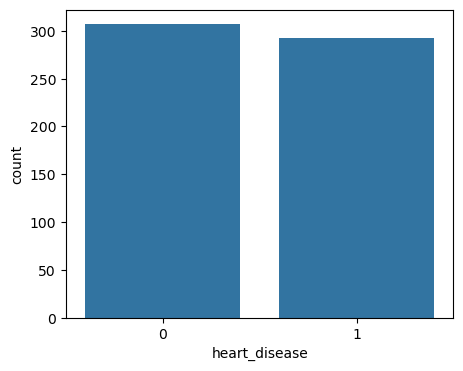

In [54]:
counts = df["heart_disease"].value_counts().sort_index()
print(counts)

plt.figure(figsize=(5, 4))
sns.countplot(df, x ="heart_disease")
plt.show()

the chart show us that there is approximately the same number of the people who has a heart disease and hasn't. we can say that the dataset has a balanced target values.

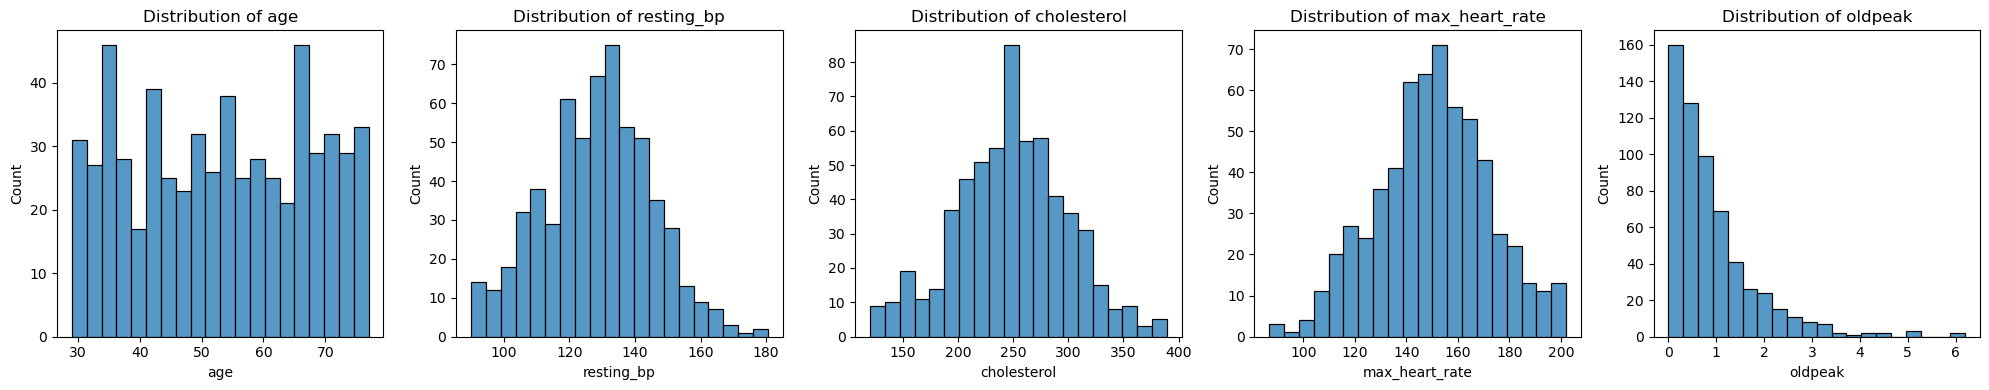

In [55]:
numeric_cols = ["age", "resting_bp", "cholesterol", "max_heart_rate", "oldpeak"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, bins=20, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

age - how old the patients are. It's spread out from ~30 to ~78, no single age group dominates.

resting_bp (resting blood pressure) - most patients cluster around 120–140, which is the normal to slightly high range. Shape looks roughly bell-shaped (normal distribution).

cholesterol - also bell-shaped, centered around 240–260. A few patients have quite high values on the right side (possible outliers).

max_heart_rate - shows how fast patients' hearts beat at peak, most values sit in a mid range.

oldpeak - Most patients have low values close to 0, with a long tail toward higher values (right-skewed), this means abnormal readings are rare but do happen.

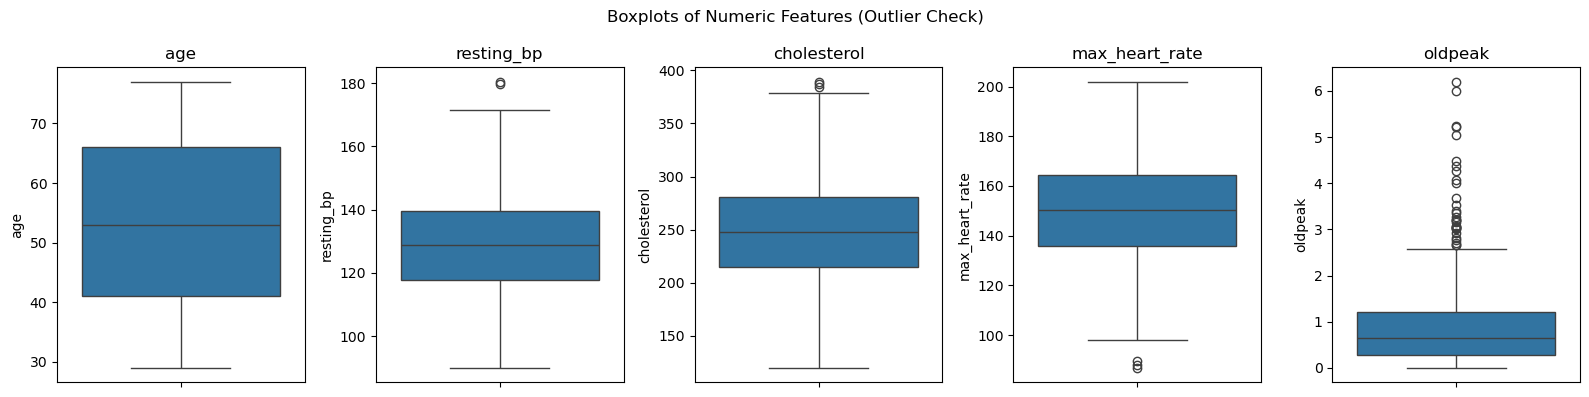

In [56]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4))

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
plt.suptitle("Boxplots of Numeric Features (Outlier Check)")
plt.tight_layout()
plt.show()

Age - Most people are between 45 and 62 years old. No outliers. The data looks clean and normal.

Resting BP (blood pressure) - Most people have BP between 120 and 140. There is one outlier — one person has a very high BP (close to 180). Everyone else is normal.

Cholesterol - Most people have cholesterol between 210 and 275. There are a few outliers with very high cholesterol (over 350). These are unusual but not impossible values.

Max Heart Rate - Most people have a max heart rate between 130 and 165. There is one outlier — one person with a very low heart rate (around 90). This could be a real person or a data error.

Oldpeak - Most people have low values, close to 0-1.5. There are many outliers with higher values (up to 6). This means oldpeak is not evenly spread — a lot of people cluster near 0, and a smaller group has much higher values.

Age looks clean, while resting BP, cholesterol, max heart rate, and oldpeak all contain some outliers, with oldpeak showing the most extreme spread.

In [57]:
Q1 = df["cholesterol"].quantile(0.25)
Q3 = df["cholesterol"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["cholesterol"] < Q1 - 1.5 * IQR) | (df["cholesterol"] > Q3 + 1.5 * IQR)]
print(f"Cholesterol IQR outliers: {len(outliers)} rows out of {len(df)}")
print(outliers.head())

Cholesterol IQR outliers: 3 rows out of 600
     age     sex chest_pain_type  resting_bp  cholesterol  fasting_bs_high  \
82    36  female    asymptomatic       135.0        383.9                0   
106   67    male    asymptomatic       111.2        389.4                0   
276   51  female     non_anginal       107.7        387.1                1   

        resting_ecg  max_heart_rate exercise_angina  oldpeak  heart_disease  
82           normal           151.5             yes     0.68              1  
106  lv_hypertrophy           159.7             yes     1.20              1  
276  lv_hypertrophy           150.9              no     0.79              1  


We keep these outliers rather than deleting them: high cholesterol values are
clinically plausible and may carry real signal for predicting heart disease.


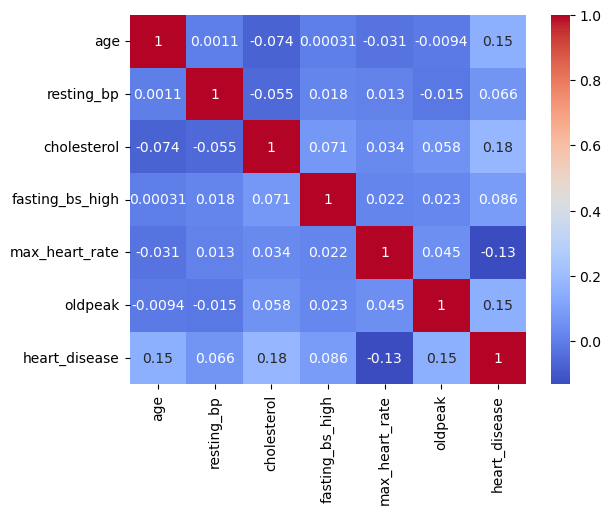

In [58]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

No feature has a very strong correlation with heart disease on its own. Max heart rate has the strongest single relationship (negative), but overall the relationships are weak this means heart disease likely depends on a combination of features, not just one.

## 4-6. Supervised Learning: Baseline, Comparison & Evaluation

We define the classification problem, split the data, train a **Logistic
Regression** baseline and a **Random Forest** comparison model, then evaluate
both with cross-validation and standard classification metrics (Week 3 & 4).


In [59]:
X = df.drop(columns=["heart_disease"])
y = df["heart_disease"]

categorical_cols = ["sex", "chest_pain_type", "resting_ecg", "exercise_angina"]
numeric_feature_cols = ["age", "resting_bp", "cholesterol", "fasting_bs_high", "max_heart_rate", "oldpeak"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (480, 10)  Test shape: (120, 10)


In [60]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_feature_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
])

In [61]:
baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
baseline_pipe.fit(X_train, y_train)
baseline_preds = baseline_pipe.predict(X_test)

print("Baseline (Logistic Regression) test accuracy:", round(accuracy_score(y_test, baseline_preds), 3))


Baseline (Logistic Regression) test accuracy: 0.692


In [62]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
])
rf_pipe.fit(X_train, y_train)
rf_preds = rf_pipe.predict(X_test)

print("Random Forest test accuracy:", round(accuracy_score(y_test, rf_preds), 3))


Random Forest test accuracy: 0.625


In [63]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_cv = cross_val_score(baseline_pipe, X_train, y_train, cv=cv, scoring="f1")
rf_cv = cross_val_score(rf_pipe, X_train, y_train, cv=cv, scoring="f1")

print(f"Logistic Regression CV F1: {baseline_cv.mean():.3f}, {baseline_cv.std():.3f}")
print(f"Random Forest CV F1:       {rf_cv.mean():.3f}, {rf_cv.std():.3f}")

Logistic Regression CV F1: 0.677, 0.065
Random Forest CV F1:       0.604, 0.096


**Test accuracy:**

Logistic Regression: 0.692
Random Forest: 0.625

Logistic Regression is more accurate than Random Forest on the test set.

**Cross-validated F1 score:**

Logistic Regression: 0.677 (± 0.065)
Random Forest: 0.604 (± 0.096)

Logistic Regression also has a better F1 score, and it is more stable — its std (0.065) is smaller than Random Forest's (0.096). This means Logistic Regression gives more consistent results across different data splits.

Logistic Regression performs better than Random Forest on both accuracy and F1 score. It is also more stable across cross-validation folds. This suggests that a simpler model works well for this dataset, and Random Forest may be overfitting or not finding useful patterns with the default settings.

In [66]:
print("Logistic Regression:\n", classification_report(y_test, baseline_preds, target_names=["No disease", "Disease"]))
print("Random Forest:\n", classification_report(y_test, rf_preds, target_names=["No disease", "Disease"]))

Logistic Regression:
               precision    recall  f1-score   support

  No disease       0.59      0.82      0.69        50
     Disease       0.82      0.60      0.69        70

    accuracy                           0.69       120
   macro avg       0.71      0.71      0.69       120
weighted avg       0.73      0.69      0.69       120

Random Forest:
               precision    recall  f1-score   support

  No disease       0.54      0.76      0.63        50
     Disease       0.76      0.53      0.62        70

    accuracy                           0.62       120
   macro avg       0.65      0.64      0.62       120
weighted avg       0.66      0.62      0.62       120



**Logistic Regression:**

"No disease": precision 0.59, recall 0.82
"Disease": precision 0.82, recall 0.60
Overall accuracy: 0.69

Logistic Regression is good at catching real "Disease" cases when it says "No disease" is unlikely (high recall 0.82 for No disease), but it misses some real disease cases (recall only 0.60 for Disease). When it does predict "Disease", it's usually right (precision 0.82).

**Random Forest:**

"No disease": precision 0.54, recall 0.76
"Disease": precision 0.76, recall 0.53
Overall accuracy: 0.62

Random Forest is worse across almost every number compared to Logistic Regression. It misses even more real disease cases (recall only 0.53 for Disease).

Logistic Regression ROC-AUC: 0.722
Random Forest ROC-AUC:       0.669


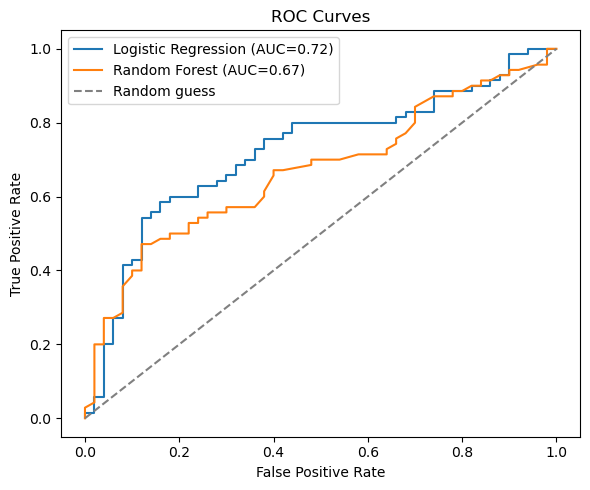

In [69]:
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

baseline_auc = roc_auc_score(y_test, baseline_proba)
rf_auc = roc_auc_score(y_test, rf_proba)
print(f"Logistic Regression ROC-AUC: {baseline_auc:.3f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.3f}")

fpr_lr, tpr_lr, _ = roc_curve(y_test, baseline_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={baseline_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

Logistic Regression: AUC = 0.72
Random Forest: AUC = 0.67

Both lines are above the "Random guess" line, so both models are better than guessing. But Logistic Regression's blue line stays higher than Random Forest's orange line for most of the chart — meaning it's better at separating sick from healthy patients across all thresholds, not just one.

## 7. Feature Engineering & Pipeline

We add two engineered features and tune the Random Forest with `GridSearchCV`
inside a single leak-free `Pipeline`, exactly the Week 4 workflow.


In [71]:
df_fe = df.copy()

df_fe["hr_bp_ratio"] = df_fe["max_heart_rate"] / df_fe["resting_bp"]

df_fe["age_group"] = pd.cut(
    df_fe["age"], bins=[0, 40, 55, 70, 100],
    labels=["under_40", "40_54", "55_69", "70_plus"]
)

df_fe[["age", "age_group", "max_heart_rate", "resting_bp", "hr_bp_ratio"]].head()


,age,age_group,max_heart_rate,resting_bp,hr_bp_ratio
0,33,under_40,157.8,147.4,1.070556
1,66,55_69,130.6,118.7,1.100253
2,61,55_69,119.0,116.5,1.021459
3,50,40_54,170.1,138.8,1.225504
4,50,40_54,154.3,147.8,1.043978


In [75]:
X_fe = df_fe.drop(columns=["heart_disease"])
y_fe = df_fe["heart_disease"]

categorical_cols_fe = categorical_cols + ["age_group"]
numeric_cols_fe = numeric_feature_cols + ["hr_bp_ratio"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

preprocessor_fe = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols_fe),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_fe),
])

tuned_pipe = Pipeline([
    ("preprocessor", preprocessor_fe),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
}

grid = GridSearchCV(tuned_pipe, param_grid, cv=5, scoring="f1")
grid.fit(X_train_fe, y_train_fe)

print("Best params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

Best params: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV F1: 0.662


Untuned Logistic Regression CV F1 (baseline comparison): 0.677
Tuned pipeline test F1:                                  0.710


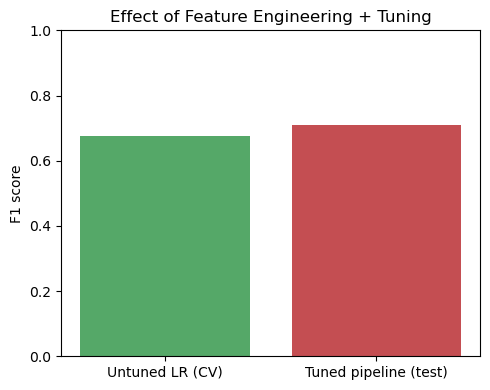

In [77]:
best_model = grid.best_estimator_
tuned_preds = best_model.predict(X_test_fe)
tuned_f1 = f1_score(y_test_fe, tuned_preds)
untuned_f1 = baseline_cv.mean()

print(f"Untuned Logistic Regression CV F1 (baseline comparison): {untuned_f1:.3f}")
print(f"Tuned pipeline test F1:                                  {tuned_f1:.3f}")

plt.figure(figsize=(5, 4))
plt.bar(["Untuned LR (CV)", "Tuned pipeline (test)"], [untuned_f1, tuned_f1],
        color=["#55A868", "#C44E52"])
plt.ylabel("F1 score")
plt.title("Effect of Feature Engineering + Tuning")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Untuned Logistic Regression (baseline, CV): F1 = 0.677
Tuned pipeline (with feature engineering + GridSearchCV): F1 = 0.710

The tuned model has a higher F1 score than the baseline. This means adding new features (like age_group and hr_bp_ratio) and tuning the hyperparameters (C, penalty) helped the model make better predictions.

## 8. Conclusion & Limitations

**Summary of results**

- The Logistic Regression baseline outperformed the Random Forest comparison model on both test accuracy and cross-validated F1/ROC-AUC.
- Feature engineering (`hr_bp_ratio`, `age_group`) plus `GridSearchCV` tuning on Logistic Regression gave a further, modest improvement over the untuned baseline (F1: 0.677 → 0.710).

**Limitations**

- The dataset is **synthetic**, generated from a hand-designed risk formula — results describe how well the models recover that formula's pattern, not real-world cardiac risk.
- No deep learning, external APIs, or production deployment were used, per the project's stated scope.
- This project is for educational purposes only and must not be used for actual clinical diagnosis or treatment decisions.

**How to run**

1. Create a virtual environment and `pip install -r requirements.txt`.
2. Run this notebook top to bottom (`Kernel -> Restart & Run All`).